# Matlab Notebook：AI 采用决策与数字化转型生产率

这份 notebook 面向 Matlab kernel 展示与调试。模型把数字化转型看作企业是否采用 AI、以及采用多少 AI 强度的优化问题：收益来自生产率提升，成本来自固定采用成本和凸性实施成本。

## 成本-收益优化问题（静态基准）

企业 $i$ 的管理能力为 $m_i$，选择 AI 使用强度 $x_i \in [0, 1]$。若采用 AI，需要支付固定采用成本；低管理能力企业还会面临更高的实施成本。净收益为：

$$V_i(x_i) = (\phi + \lambda m_i)x_i - \frac{1}{2}\psi x_i^2 - c_i.$$

企业先求 $x_i^* = \arg\max_{x_i \in [0,1]} V_i(x_i)$，再比较 $V_i(x_i^*)$ 是否大于 0。若净收益为正则采用 AI，否则不采用。这里用 Matlab 的 `fminbnd` 展示单个企业的强度优化，也用有界优化将 $\phi$ 校准到模拟 DID 的平均处理效应。

In [2]:
output_dir = fullfile('..', 'output');
did_file = fullfile(output_dir, 'stata_did_results.csv');
if exist(did_file, 'file')
    did_results = readtable(did_file);
    target_effect = did_results.estimate(1);
else
    target_effect = 0.12;
end
managerial_capability = linspace(-1.5, 1.5, 61)';
psi = 1.8;
lambda = 0.12;
fixed_ai_cost = 0.06;
cost_sensitivity = 0.10;
ai_setup_cost = fixed_ai_cost + cost_sensitivity .* max(-managerial_capability, 0);
net_value = @(x, m, phi, cost) (phi + lambda .* m) .* x - 0.5 .* psi .* x.^2 - cost;
representative_capability = 0.5;
representative_cost = fixed_ai_cost + cost_sensitivity * max(-representative_capability, 0);
phi_guess = 0.35;
[x_star, negative_value] = fminbnd(@(x) -net_value(x, representative_capability, phi_guess, representative_cost), 0, 1);
representative_net_benefit = -negative_value;
adopt_representative = representative_net_benefit > 0;
table(representative_capability, representative_cost, x_star, representative_net_benefit, adopt_representative)


ans =

  1x5 table

    representative_capability    representative_cost    x_star     representative_net_benefit    adopt_representative
    _________________________    ___________________    _______    __________________________    ____________________

               0.5                      0.06            0.22778            -0.013306                    false        



In [7]:
candidate_intensity = @(phi) min(max((phi + lambda .* managerial_capability) ./ psi, 0), 1);
net_benefit = @(phi) (phi + lambda .* managerial_capability) .* candidate_intensity(phi) - 0.5 .* psi .* candidate_intensity(phi).^2 - ai_setup_cost;
realized_gain = @(phi) max(net_benefit(phi), 0);
objective = @(phi) (mean(realized_gain(phi)) - target_effect)^2;
phi_hat = fminbnd(objective, 0, 2);
ai_intensity = candidate_intensity(phi_hat);
net_benefit_if_adopt = net_benefit(phi_hat);
adopt_ai = net_benefit_if_adopt > 0;
ai_intensity(~adopt_ai) = 0;
productivity_gain = max(net_benefit_if_adopt, 0);
productivity_level = exp(productivity_gain);
adoption_share = mean(adopt_ai);
table(target_effect, phi_hat, adoption_share, mean(productivity_gain), std(productivity_gain))


ans =

  1x5 table

    target_effect    phi_hat    adoption_share     Var4        Var5  
    _____________    _______    ______________    _______    ________

       0.12092       0.86589       0.81967        0.12092    0.085241



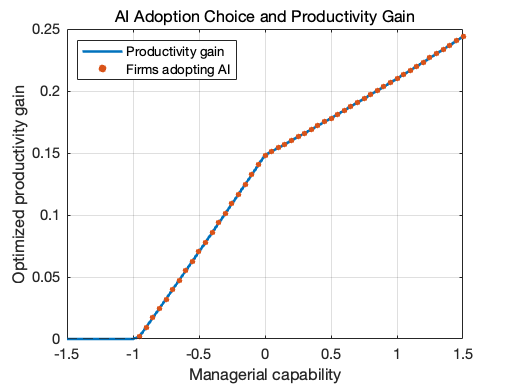

In [8]:
plot(managerial_capability, productivity_gain, 'LineWidth', 2); hold on;
scatter(managerial_capability(adopt_ai), productivity_gain(adopt_ai), 18, 'filled');
yline(0, '--');
xlabel('Managerial capability');
ylabel('Optimized productivity gain');
title('AI Adoption Choice and Productivity Gain');
legend('Productivity gain', 'Firms adopting AI', 'Location', 'northwest');
grid on;

## 动态拓展

将静态模型拓展为两期动态决策：

- **第 1 期**：企业以传统方式运营，期末观察到自身管理能力 $m_i$，决定是否支付采用成本 $c_i$ 进行数字化转型。
- **第 2 期**：若已转型，企业选择最优 AI 使用强度 $x_i^*$ 并获得生产率收益；若未转型，收益为 0。

第 2 期的最优强度与静态模型一致：

$$x_i^* = \arg\max_{x_i \in [0,1]} \left[(\phi + \lambda m_i)x_i - \frac{1}{2}\psi x_i^2\right] = \min\left(\max\left(\frac{\phi + \lambda m_i}{\psi}, 0\right), 1\right).$$

第 2 期的优化收益为 $\Pi_i^* = (\phi + \lambda m_i)x_i^* - \frac{1}{2}\psi (x_i^*)^2$。企业在第 1 期期末比较：

$$V_i^{\text{adopt}} = -c_i + \beta \cdot \Pi_i^*, \quad V_i^{\text{no}} = 0.$$

其中 $\beta \in (0, 1]$ 为折现因子。企业当且仅当 $V_i^{\text{adopt}} > 0$ 时选择转型。

**与静态模型的区别**：
- 静态模型要求当期收益覆盖当期成本：$\Pi_i^* > c_i$。
- 动态模型只要求折现后收益覆盖当期成本：$\beta\Pi_i^* > c_i$。当 $\beta < 1$ 时，采用门槛更高，采用率更低。

In [ ]:
% 动态模型参数
beta = 0.95;   % 折现因子（第二期收益的现值权重）

% 使用与静态模型相同的 phi_hat 和参数
% 第 2 期最优强度（与静态模型一致，但不扣 c_i）
ai_intensity_dyn = candidate_intensity(phi_hat);    % [0,1] 内的最优强度
pi_star = (phi_hat + lambda .* managerial_capability) .* ai_intensity_dyn ...
          - 0.5 .* psi .* ai_intensity_dyn.^2;      % 第 2 期优化收益（不含采用成本）

% 第 1 期期末净现值
npv_adopt = -ai_setup_cost + beta .* pi_star;       % V_i^adopt

% 动态采用决策
adopt_dyn = npv_adopt > 0;
ai_intensity_dyn(~adopt_dyn) = 0;
productivity_gain_dyn = max(npv_adopt, 0);
adoption_share_dyn = mean(adopt_dyn);

% 对比静态与动态结果
comparison = table( ...
    mean(adopt_ai), adoption_share_dyn, ...
    mean(productivity_gain), mean(productivity_gain_dyn), ...
    'VariableNames', {'Static_Adoption', 'Dynamic_Adoption', ...
                      'Static_AvgGain', 'Dynamic_AvgGain'});
disp(comparison)

% 找到静态与动态采用决策不同的边界企业
disagree = adopt_ai ~= adopt_dyn;
fprintf('静态采用但动态不采用的企业数: %d / %d\n', ...
    sum(adopt_ai & ~adopt_dyn), sum(disagree));

In [ ]:
figure;
tiledlayout(1, 2);

% 左图：两期 NPV 曲线
nexttile;
yyaxis left;
plot(managerial_capability, npv_adopt, 'b-', 'LineWidth', 2);
yline(0, 'k--');
ylabel('NPV of adoption (V_i^{adopt})');
yyaxis right;
plot(managerial_capability, ai_setup_cost, 'r-', 'LineWidth', 1.5);
ylabel('Adoption cost (c_i)');
xlabel('Managerial capability (m_i)');
title(sprintf('Dynamic Model (\\beta = %.2f)', beta));
legend('NPV', 'Break-even', 'Cost', 'Location', 'northwest');
grid on;

% 右图：静态 vs 动态采用
nexttile;
scatter(managerial_capability(adopt_ai & adopt_dyn), ...
    productivity_gain(adopt_ai & adopt_dyn), 12, [0 0.5 0], 'filled'); hold on;
scatter(managerial_capability(adopt_ai & ~adopt_dyn), ...
    productivity_gain(adopt_ai & ~adopt_dyn), 18, 'r', 'filled');
scatter(managerial_capability(~adopt_ai & ~adopt_dyn), ...
    productivity_gain(~adopt_ai & ~adopt_dyn), 12, [0.7 0.7 0.7], 'filled');
xlabel('Managerial capability');
ylabel('Productivity gain');
title('Static vs Dynamic Adoption');
legend('Both adopt', 'Static only (dynamic drops)', 'Neither adopts', ...
    'Location', 'northwest');
grid on;

In [9]:
run('../scripts/matlab_power_simulation.m')

Target DID effect: 0.121
Calibrated phi: 0.866
Mean model-implied gain: 0.121
AI adoption share: 0.820
